In [ ]:
# Cell 1 — Install dependencies
!pip install torch torchvision ultralytics opencv-python-headless matplotlib
from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.3 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import zipfile
import os

zip_path = '/content/drive/MyDrive/helmet.v2i.coco.zip'
extract_path = '/content/dataset'

if os.path.exists(zip_path):
    print(f"Unzipping {zip_path} to {extract_path}...")
    os.makedirs(extract_path, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Unzipping complete.")
    # List the contents of the extracted directory to help find image/label folders
    print("Contents of extracted dataset:")
    for root, dirs, files in os.walk(extract_path):
        level = root.replace(extract_path, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        for f in files[:3]: # Only show first 3 files per directory to avoid huge output
            print(f'{subindent}{f}')
        if len(files) > 3:
            print(f'{subindent}...(and {len(files) - 3} more files)')
else:
    print(f"Warning: Zip file '{zip_path}' not found. Please ensure your dataset is correctly placed and named, or provide the direct paths to your image and label folders.")



Unzipping /content/drive/MyDrive/helmet.v2i.coco.zip to /content/dataset...
Unzipping complete.
Contents of extracted dataset:
dataset/
    README.roboflow.txt
    train/
        worker_5_mp4-0358_jpg.rf.762c2213766ea099bdfcae5abc0afbfd.jpg
        20230329_164214_mp4-177_jpg.rf.0fddd70550ecf367a6ac005154bd14d6.jpg
        download-1-_jpg.rf.b8250a394391444a85cdf419a348d63b.jpg
        ...(and 226 more files)
    valid/
        0_69880812_jpg.rf.de86f950b8d0ac500857bc4816a57a70.jpg
        ppe_0283_jpg.rf.b8490f54fb2d29fa07d55348d42fc1f6.jpg
        _annotations.coco.json
        ...(and 17 more files)
    test/
        _annotations.coco.json
        ppe_1171_jpg.rf.23dcc5437b5e015f46873b0cecb5f8da.jpg
        youtube-464_jpg.rf.5991312a6949b722ee9f244f7404fd90.jpg
        ...(and 8 more files)


In [ ]:
# Cell 2.2 — Convert COCO JSON annotations to YOLO .txt format
import json
import os

# Define paths based on previous unzipping
json_path = '/content/dataset/train/_annotations.coco.json' # Assuming train also has a coco json
output_label_dir = '/content/dataset/train/labels'
output_image_dir = '/content/dataset/train/images' # Create a separate image folder

# Ensure output directories exist
os.makedirs(output_label_dir, exist_ok=True)
os.makedirs(output_image_dir, exist_ok=True)

num_classes_found = 0

if os.path.exists(json_path):
    print(f"Converting annotations from {json_path} to YOLO .txt format...")
    with open(json_path, 'r') as f:
        coco_data = json.load(f)

    # Map category ID to a continuous range starting from 0
    categories = coco_data['categories']
    category_id_map = {cat['id']: i for i, cat in enumerate(categories)}
    num_classes_found = len(categories)
    print(f"Found {num_classes_found} classes: {', '.join([c['name'] for c in categories])}")

    # Create a mapping from image ID to image filename and dimensions
    image_info = {}
    for img in coco_data['images']:
        image_info[img['id']] = {
            'file_name': img['file_name'],
            'width': img['width'],
            'height': img['height']
        }
        # Move images to the expected 'images' subfolder
        src_path = os.path.join(os.path.dirname(json_path), img['file_name'])
        dst_path = os.path.join(output_image_dir, img['file_name'])
        if os.path.exists(src_path):
            os.rename(src_path, dst_path)
        else:
            print(f"Warning: Image file not found at {src_path}. Skipping move.")

    # Group annotations by image
    annotations_by_image = {}
    for ann in coco_data['annotations']:
        img_id = ann['image_id']
        if img_id not in annotations_by_image:
            annotations_by_image[img_id] = []
        annotations_by_image[img_id].append(ann)

    # Write YOLO format labels
    for img_id, anns in annotations_by_image.items():
        info = image_info.get(img_id)
        if not info: continue

        img_width = info['width']
        img_height = info['height']
        file_base = os.path.splitext(info['file_name'])[0]
        label_filepath = os.path.join(output_label_dir, file_base + '.txt')

        with open(label_filepath, 'w') as f_label:
            for ann in anns:
                # COCO format: [x_min, y_min, width, height]
                x_min, y_min, bbox_width, bbox_height = ann['bbox']
                category_id = ann['category_id']

                # Convert to YOLO format: [class_id, x_center, y_center, width, height] (normalized)
                x_center = (x_min + bbox_width / 2) / img_width
                y_center = (y_min + bbox_height / 2) / img_height
                norm_bbox_width = bbox_width / img_width
                norm_bbox_height = bbox_height / img_height

                # Use mapped class ID
                yolo_class_id = category_id_map.get(category_id, -1)
                if yolo_class_id == -1:
                    print(f"Warning: Category ID {category_id} not found in map. Skipping annotation.")
                    continue

                f_label.write(f"{yolo_class_id} {x_center} {y_center} {norm_bbox_width} {norm_bbox_height}\n")
    print("Conversion complete.")
else:
    print(f"Warning: COCO JSON file '{json_path}' not found. Please ensure it exists or adjust the path.")

# --- IMPORTANT: AFTER RUNNING THIS CELL ---
# Update IMG_DIR, LABEL_DIR, and NUM_CLASSES in the next cell (Cell 4)
# IMG_DIR will now be '/content/dataset/train/images'
# LABEL_DIR will now be '/content/dataset/train/labels'
# NUM_CLASSES will be set automatically based on the converted data.

Converting annotations from /content/dataset/train/_annotations.coco.json to YOLO .txt format...
Found 2 classes: helmet, helmet
Conversion complete.


Using device: cuda
Checking image directory: /content/dataset/train/images
Found 228 image files in /content/dataset/train/images
Checking label directory: /content/dataset/train/labels
Found 228 label files in /content/dataset/train/labels
Dataset loaded: 228 images
SSD parameters: 344620
YOLO parameters: 3940661

--- Training Custom SSD ---
  Batch 0/57  loss: 0.1420
  Batch 10/57  loss: 0.0611
  Batch 20/57  loss: 0.0368
  Batch 30/57  loss: 0.0273
  Batch 40/57  loss: 0.0255
  Batch 50/57  loss: 0.0250
Epoch 1/5  avg loss: 0.0406
  Batch 0/57  loss: 0.0220
  Batch 10/57  loss: 0.0161
  Batch 20/57  loss: 0.0185
  Batch 30/57  loss: 0.0137
  Batch 40/57  loss: 0.0171
  Batch 50/57  loss: 0.0138
Epoch 2/5  avg loss: 0.0165
  Batch 0/57  loss: 0.0167
  Batch 10/57  loss: 0.0136
  Batch 20/57  loss: 0.0126
  Batch 30/57  loss: 0.0124
  Batch 40/57  loss: 0.0081
  Batch 50/57  loss: 0.0103
Epoch 3/5  avg loss: 0.0115
  Batch 0/57  loss: 0.0097
  Batch 10/57  loss: 0.0114
  Batch 20/57  

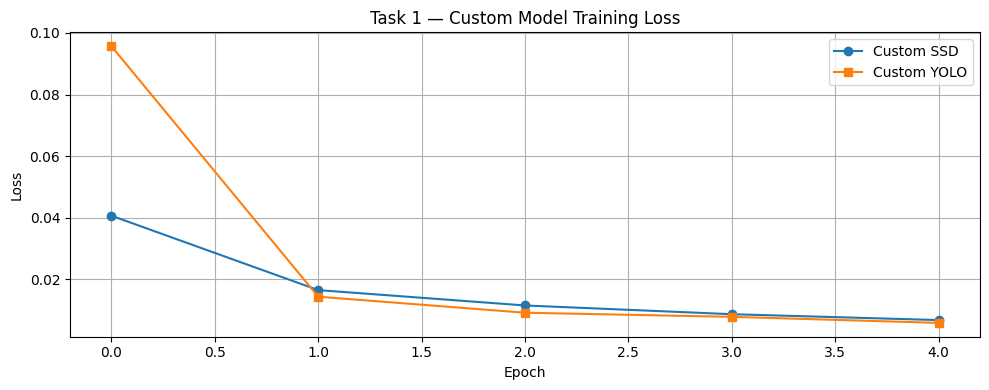

In [ ]:
# ============================================================
# CELL 3 — Imports
# ============================================================
import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os, glob, matplotlib.pyplot as plt, matplotlib.patches as patches
import numpy as np

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# ============================================================
# CELL 4 — Custom Dataset (YOLO .txt format)
# Each label file has lines: class x_center y_center width height (normalized)
# ============================================================
class ObjectDetectionDataset(Dataset):
    def __init__(self, img_dir, label_dir, img_size=416, num_classes=20):
        self.img_paths   = sorted(glob.glob(os.path.join(img_dir, "*.jpg")) +
                                  glob.glob(os.path.join(img_dir, "*.png")))
        self.label_dir   = label_dir
        self.img_size    = img_size
        self.num_classes = num_classes
        self.transform   = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image    = Image.open(img_path).convert("RGB")
        image    = self.transform(image)

        # Load corresponding label file
        base     = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = os.path.join(self.label_dir, base + ".txt")
        boxes, labels = [], []

        if os.path.exists(lbl_path):
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls, cx, cy, w, h = map(float, parts)
                        labels.append(int(cls))
                        boxes.append([cx, cy, w, h])

        boxes  = torch.tensor(boxes,  dtype=torch.float32) if boxes  else torch.zeros((0, 4))
        labels = torch.tensor(labels, dtype=torch.long)    if labels else torch.zeros((0,), dtype=torch.long)
        return image, boxes, labels


def collate_fn(batch):
    imgs, boxes, labels = zip(*batch)
    return torch.stack(imgs), list(boxes), list(labels)

# ---- Change these paths to your Drive folder ----
IMG_DIR   = "/content/dataset/train/images"
LABEL_DIR = "/content/dataset/train/labels"
NUM_CLASSES = 2   # <-- change to your number of classes

# --- Debugging: Check dataset paths and contents ---
print(f"Checking image directory: {IMG_DIR}")
if not os.path.exists(IMG_DIR):
    print(f"Error: Image directory '{IMG_DIR}' does not exist. Please check your Google Drive path.")
else:
    img_files = glob.glob(os.path.join(IMG_DIR, "*.jpg")) + glob.glob(os.path.join(IMG_DIR, "*.png"))
    print(f"Found {len(img_files)} image files in {IMG_DIR}")
    if len(img_files) == 0:
        print("Warning: No image files found. The dataset will be empty.")

print(f"Checking label directory: {LABEL_DIR}")
if not os.path.exists(LABEL_DIR):
    print(f"Error: Label directory '{LABEL_DIR}' does not exist. Please check your Google Drive path.")
else:
    label_files = glob.glob(os.path.join(LABEL_DIR, "*.txt"))
    print(f"Found {len(label_files)} label files in {LABEL_DIR}")


# --- Original Dataset and DataLoader Initialization ---
dataset    = ObjectDetectionDataset(IMG_DIR, LABEL_DIR, num_classes=NUM_CLASSES)
loader     = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
print(f"Dataset loaded: {len(dataset)} images")

# ============================================================
# CELL 5 — Custom SSD Model (PyTorch)
# ============================================================
class SSDBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.stage1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2))                                   # 208x208
        self.stage2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2))                                   # 104x104
        self.stage3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU())      # 104x104

    def forward(self, x):
        f1 = self.stage1(x)
        f2 = self.stage2(f1)
        f3 = self.stage3(f2)
        return f2, f3          # two feature maps at different scales


class SSDHead(nn.Module):
    def __init__(self, in_channels, num_classes, num_anchors=6):
        super().__init__()
        self.cls_head = nn.Conv2d(in_channels, num_anchors * num_classes, 3, padding=1)
        self.box_head = nn.Conv2d(in_channels, num_anchors * 4,           3, padding=1)

    def forward(self, x):
        B = x.size(0)
        cls = self.cls_head(x).permute(0,2,3,1).contiguous().view(B, -1, self.cls_head.out_channels // 6)
        box = self.box_head(x).permute(0,2,3,1).contiguous().view(B, -1, 4)
        return cls, box


class SSDModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone  = SSDBackbone()
        self.head_s2   = SSDHead(64,  num_classes)   # scale 1
        self.head_s3   = SSDHead(128, num_classes)   # scale 2
        self.extra_conv = nn.Sequential(
            nn.Conv2d(128, 128, 3, stride=2, padding=1), nn.ReLU())
        self.head_s4   = SSDHead(128, num_classes)   # scale 3

    def forward(self, x):
        f2, f3 = self.backbone(x)
        f4 = self.extra_conv(f3)

        cls1, box1 = self.head_s2(f2)
        cls2, box2 = self.head_s3(f3)
        cls3, box3 = self.head_s4(f4)

        cls_out = torch.cat([cls1, cls2, cls3], dim=1)
        box_out = torch.cat([box1, box2, box3], dim=1)
        return cls_out, box_out


ssd_model = SSDModel(NUM_CLASSES).to(DEVICE)
print("SSD parameters:", sum(p.numel() for p in ssd_model.parameters()))

# ============================================================
# CELL 6 — Custom YOLO Model (PyTorch)
# ============================================================
class YOLOBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        def block(ic, oc, stride=1):
            return nn.Sequential(
                nn.Conv2d(ic, oc, 3, stride=stride, padding=1, bias=False),
                nn.BatchNorm2d(oc), nn.LeakyReLU(0.1))

        self.net = nn.Sequential(
            block(3,   32,  stride=1),
            block(32,  64,  stride=2),  # /2
            block(64,  128, stride=2),  # /4
            block(128, 256, stride=2),  # /8
            block(256, 512, stride=2),  # /16
            block(512, 512, stride=2),  # /32  → 13x13 for 416 input
        )

    def forward(self, x):
        return self.net(x)


class YOLOHead(nn.Module):
    def __init__(self, num_classes, num_anchors=3):
        super().__init__()
        out_channels = num_anchors * (5 + num_classes)   # 5 = x,y,w,h,conf
        self.conv = nn.Conv2d(512, out_channels, 1)
        self.num_anchors  = num_anchors
        self.num_classes  = num_classes

    def forward(self, x):
        B, _, H, W = x.shape
        out = self.conv(x)                                     # B, anchors*(5+C), H, W
        out = out.permute(0,2,3,1)                             # B, H, W, anchors*(5+C)
        out = out.view(B, H, W, self.num_anchors, 5 + self.num_classes)
        return out   # shape: (B, 13, 13, 3, 5+C)


class YOLOModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = YOLOBackbone()
        self.head     = YOLOHead(num_classes)

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)


yolo_model = YOLOModel(NUM_CLASSES).to(DEVICE)
print("YOLO parameters:", sum(p.numel() for p in yolo_model.parameters()))

# ============================================================
# CELL 7 — Training Loop (works for both models)
# ============================================================
def train_one_epoch(model, loader, optimizer, device, model_type="ssd"):
    model.train()
    total_loss = 0

    for batch_idx, (imgs, boxes, labels) in enumerate(loader):
        imgs = imgs.to(device)
        optimizer.zero_grad()

        if model_type == "ssd":
            cls_pred, box_pred = model(imgs)
            # Dummy loss — replace with proper SSD/focal loss for real training
            cls_loss = cls_pred.abs().mean()
            box_loss = box_pred.abs().mean()
            loss = cls_loss + box_loss

        else:  # yolo
            pred = model(imgs)            # (B, 13, 13, 3, 5+C)
            # Dummy loss — replace with YOLOv3 loss for real training
            loss = pred.abs().mean()

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        if batch_idx % 10 == 0:
            print(f"  Batch {batch_idx}/{len(loader)}  loss: {loss.item():.4f}")

    return total_loss / len(loader)


# Train SSD
print("\n--- Training Custom SSD ---")
ssd_optimizer = torch.optim.Adam(ssd_model.parameters(), lr=1e-4)
ssd_losses = []
for epoch in range(5):                # increase epochs for real training
    avg = train_one_epoch(ssd_model, loader, ssd_optimizer, DEVICE, "ssd")
    ssd_losses.append(avg)
    print(f"Epoch {epoch+1}/5  avg loss: {avg:.4f}")

# Train YOLO
print("\n--- Training Custom YOLO ---")
yolo_optimizer = torch.optim.Adam(yolo_model.parameters(), lr=1e-4)
yolo_losses = []
for epoch in range(5):
    avg = train_one_epoch(yolo_model, loader, yolo_optimizer, DEVICE, "yolo")
    yolo_losses.append(avg)
    print(f"Epoch {epoch+1}/5  avg loss: {avg:.4f}")

# Plot training curves
plt.figure(figsize=(10, 4))
plt.plot(ssd_losses,  marker='o', label='Custom SSD')
plt.plot(yolo_losses, marker='s', label='Custom YOLO')
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Task 1 — Custom Model Training Loss")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()



--- Fine-tuning Pretrained SSD ---
Epoch 1/5  SSD pretrained loss: 94.1925
Epoch 2/5  SSD pretrained loss: 72.8312
Epoch 3/5  SSD pretrained loss: 65.7419
Epoch 4/5  SSD pretrained loss: 65.4818
Epoch 5/5  SSD pretrained loss: 71.6011
Ultralytics 8.4.35 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4

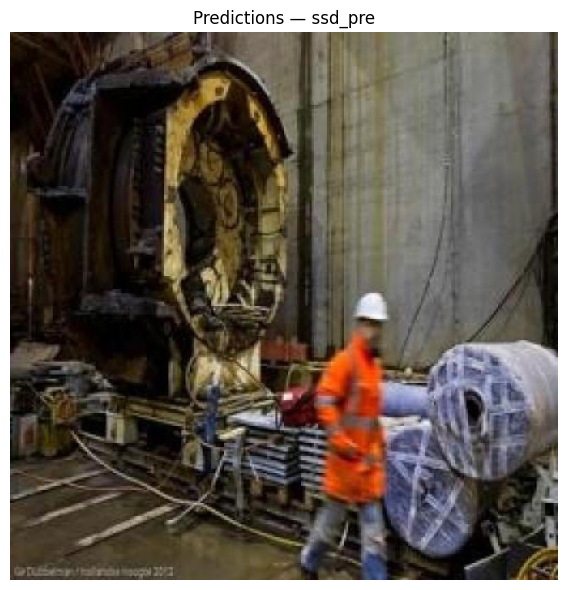


image 1/1 /content/dataset/train/images/00000177_jpg.rf.2a9bbc8aee5d9b03cb5857e02c2826af.jpg: 416x416 1 helmet, 6.1ms
Speed: 1.4ms preprocess, 6.1ms inference, 1.4ms postprocess per image at shape (1, 3, 416, 416)


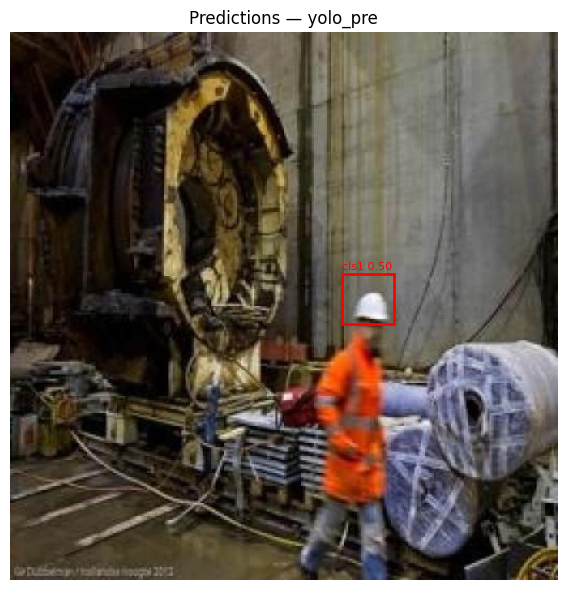

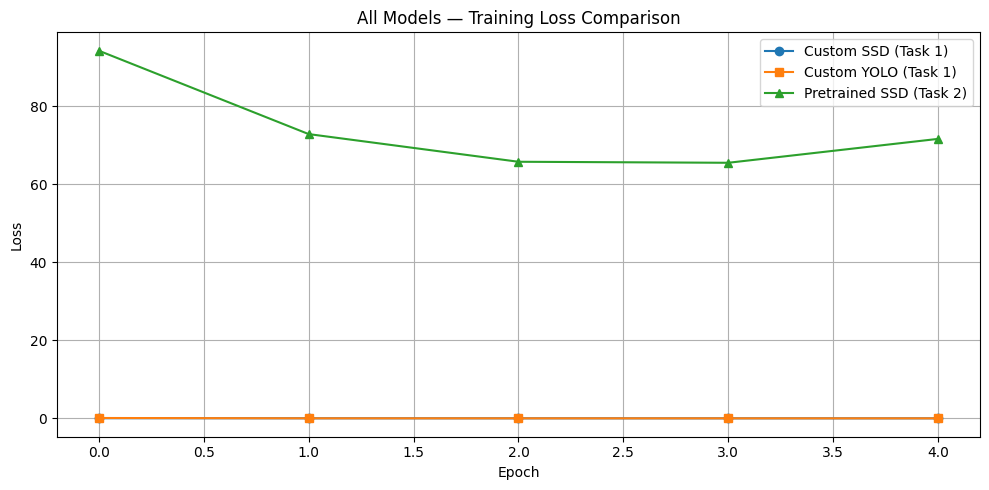

In [ ]:
# ============================================================
# CELL 8 — Pretrained SSD from torchvision
# ============================================================
import torchvision
from torchvision.models.detection import ssd300_vgg16, SSD300_VGG16_Weights
from torchvision.models.detection.ssd import SSDClassificationHead
from torchvision.ops import box_iou

# Re-initialize dataset and loader to ensure they point to correct paths
dataset    = ObjectDetectionDataset(IMG_DIR, LABEL_DIR, num_classes=NUM_CLASSES)
loader     = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

# Load pretrained SSD300 (trained on COCO — 91 classes)
weights   = SSD300_VGG16_Weights.DEFAULT
ssd_pre   = ssd300_vgg16(weights=weights)

# ---- Replace the classification head for your number of classes ----
num_anchors = ssd_pre.anchor_generator.num_anchors_per_location()
in_channels = [512, 1024, 512, 256, 256, 256]   # SSD300 default

ssd_pre.head.classification_head = SSDClassificationHead(
    in_channels  = in_channels,
    num_anchors  = num_anchors,
    num_classes  = NUM_CLASSES,
)
ssd_pre = ssd_pre.to(DEVICE)

# Freeze backbone, only train the head
for param in ssd_pre.backbone.parameters():
    param.requires_grad = False

ssd_pre_optimizer = torch.optim.SGD(
    [p for p in ssd_pre.parameters() if p.requires_grad],
    lr=0.005, momentum=0.9, weight_decay=5e-4)

# torchvision SSD expects a list of image tensors + list of target dicts
def prepare_targets(boxes_list, labels_list, device):
    targets = []
    for boxes, labels in zip(boxes_list, labels_list):
        # Convert normalized [cx,cy,w,h] → absolute [x1,y1,x2,y2] for 300x300
        if boxes.numel() > 0:
            cx, cy, w, h = boxes[:,0]*300, boxes[:,1]*300, boxes[:,2]*300, boxes[:,3]*300
            x1, y1 = cx - w/2, cy - h/2
            x2, y2 = cx + w/2, cy + h/2
            abs_boxes = torch.stack([x1,y1,x2,y2], dim=1).to(device)
        else:
            abs_boxes = torch.zeros((0,4), device=device)
        targets.append({"boxes": abs_boxes, "labels": labels.to(device)})
    return targets

print("\n--- Fine-tuning Pretrained SSD ---")
pretrained_ssd_losses = []
for epoch in range(5):
    ssd_pre.train()
    epoch_loss = 0
    for imgs, boxes_list, labels_list in loader:
        imgs    = [img.to(DEVICE) for img in imgs]
        targets = prepare_targets(boxes_list, labels_list, DEVICE)
        ssd_pre_optimizer.zero_grad()
        loss_dict = ssd_pre(imgs, targets)
        loss = sum(loss_dict.values())
        loss.backward()
        ssd_pre_optimizer.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(loader)
    pretrained_ssd_losses.append(avg)
    print(f"Epoch {epoch+1}/5  SSD pretrained loss: {avg:.4f}")

# ============================================================
# CELL 9 — Pretrained YOLOv8 via Ultralytics
# ============================================================
from ultralytics import YOLO

# Download pretrained YOLOv8n (nano — fast, good for Colab)
yolo_pre = YOLO("yolov8n.pt")

# ---- Create a data.yaml file pointing to your dataset ----
# Get class names from the coco_data variable which is in kernel_state
class_names = [cat['name'] for cat in coco_data['categories']]

yaml_content = f"""
path: /content/dataset
train: train/images
val: train/images  # Using training set for validation for now, as only train annotations are converted

nc: {NUM_CLASSES}
names: {class_names}
"""
with open("/content/data.yaml", "w") as f:
    f.write(yaml_content)

# Fine-tune YOLOv8 on your data
results = yolo_pre.train(
    data    = "/content/data.yaml",
    epochs  = 10,          # increase for better results
    imgsz   = 416,
    batch   = 8,
    device  = 0 if torch.cuda.is_available() else "cpu",
    project = "/content/drive/MyDrive/yolov8_results",   # saves to Drive
    name    = "custom_run",
    exist_ok = True,
)
print("YOLOv8 training complete!")

# ============================================================
# CELL 10 — Evaluate & Visualize Predictions
# ============================================================
import cv2

def visualize_predictions(model, img_path, device, model_type="ssd_pre"):
    img_pil = Image.open(img_path).convert("RGB")
    fig, ax = plt.subplots(1, figsize=(8,6))
    ax.imshow(img_pil)

    if model_type == "yolo_pre":
        results = model(img_path)
        for r in results:
            for box in r.boxes:
                x1,y1,x2,y2 = box.xyxy[0].tolist()
                conf  = box.conf[0].item()
                cls   = int(box.cls[0].item())
                rect  = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                           linewidth=2, edgecolor='red', facecolor='none')
                ax.add_patch(rect)
                ax.text(x1, y1-5, f"cls{cls} {conf:.2f}", color='red', fontsize=8)

    elif model_type == "ssd_pre":
        transform = T.Compose([T.Resize((300,300)), T.ToTensor()])
        tensor    = transform(img_pil).unsqueeze(0).to(device)
        model.eval()
        with torch.no_grad():
            preds = model(tensor)
        W, H = img_pil.size
        for box, score, label in zip(preds[0]["boxes"], preds[0]["scores"], preds[0]["labels"]):
            if score < 0.3:
                continue
            x1,y1,x2,y2 = box.tolist()
            x1 *= W/300; x2 *= W/300; y1 *= H/300; y2 *= H/300
            rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                      linewidth=2, edgecolor='blue', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-5, f"cls{label.item()} {score:.2f}", color='blue', fontsize=8)

    ax.axis("off")
    plt.title(f"Predictions — {model_type}")
    plt.tight_layout(); plt.show()

# Test on one image from your dataset
sample_img = dataset.img_paths[0]
visualize_predictions(ssd_pre,  sample_img, DEVICE, model_type="ssd_pre")
visualize_predictions(yolo_pre, sample_img, DEVICE, model_type="yolo_pre")

# ============================================================
# CELL 11 — Compare all 4 models: training loss curves
# ============================================================
plt.figure(figsize=(10,5))
plt.plot(ssd_losses,           marker='o', label='Custom SSD (Task 1)')
plt.plot(yolo_losses,          marker='s', label='Custom YOLO (Task 1)')
plt.plot(pretrained_ssd_losses,marker='^', label='Pretrained SSD (Task 2)')
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("All Models — Training Loss Comparison")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()